- [] Analyze category correlation to views/likes/dislikes etc
- [] Analyze relationship between US category popularity and other countries

### ToDo:
- Evolution of Category popularity over time in some capacity (days, weeks, whatever)
- Correlation between category and likes/dislikes
- Correlation between category and comment count
- Correlation between category and all numerics lmao
- Compare above information to other countries

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def make_tag_dict(filepath):
    cat = pd.read_json(filepath)
    new_dict = {}
    for i in range(len(cat["items"])):
        new_dict[cat["items"][i]["id"]] = cat["items"][i]["snippet"]["title"]
    
    return new_dict

fetch_dict = make_tag_dict("data/US_category_id.json")

def fetch_tag(category_id):
    return fetch_dict[str(category_id)]

def clean_dataframe(df):
    df["category_name"] = df["category_id"].apply(fetch_tag)
    df_reduced = df.drop(columns=["thumbnail_link", "video_id", "comments_disabled", "description", "ratings_disabled", "video_error_or_removed"])
    df_reduced["trending_date"] = pd.to_datetime(df_reduced["trending_date"], format="%y.%d.%m")
    #df_reduced["trending_yr_mo"] = 
    df_reduced["publish_time"] = pd.to_datetime(df_reduced["publish_time"])
    return df_reduced

def plot_categories(df, category, country, aggregation='mean'):
        df = (df[df["category_name"] == category].groupby(pd.Grouper(key="trending_date", freq='W'))["views"].sum())/(df.groupby(pd.Grouper(key="trending_date", freq='W'))["views"].sum())*100
        df = df.reset_index()
        ax = plt.plot(df["trending_date"], df["views"], label=f'{country}: {category}')
        return ax

#print(fetch_tag("43"))

### Introduce Clean Datasets

In [ ]:
us_df = pd.read_csv("data/USvideos.csv")
us_df_reduced = clean_dataframe(us_df)

ru_df = pd.read_csv("data/RUvideos.csv", encoding='Latin-1')
ru_df_reduced = clean_dataframe(ru_df)

### Exploration

In [ ]:
us_df_reduced.groupby("category_id")["views"].sum().sort_values(ascending=False)

us_df_reduced.corr(numeric_only=True)


,category_id,views,likes,dislikes,comment_count
category_id,1.000000,-0.168231,-0.173921,-0.033547,-0.076307
views,-0.168231,1.000000,0.849177,0.472213,0.617621
likes,-0.173921,0.849177,1.000000,0.447186,0.803057
dislikes,-0.033547,0.472213,0.447186,1.000000,0.700184
comment_count,-0.076307,0.617621,0.803057,0.700184,1.000000


<Axes: ylabel='category_name'>

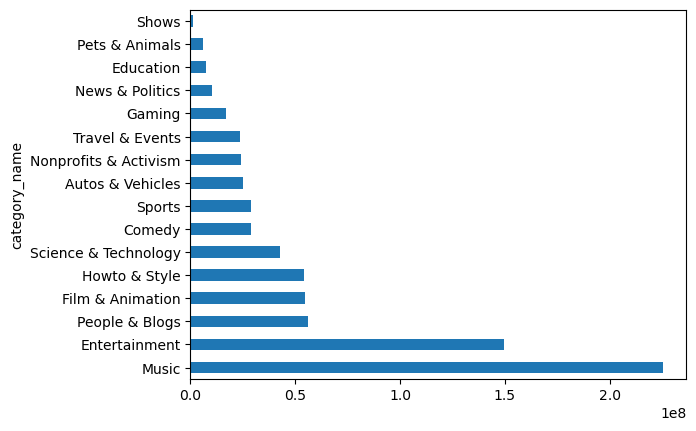

In [ ]:
most_viewed_in_each_category = us_df_reduced.groupby("category_name")["views"].max().sort_values(ascending=False)
most_viewed_in_each_category.plot(kind="barh")

# WE LEFT OFF IN THE CELL BELOW
  |  
 V

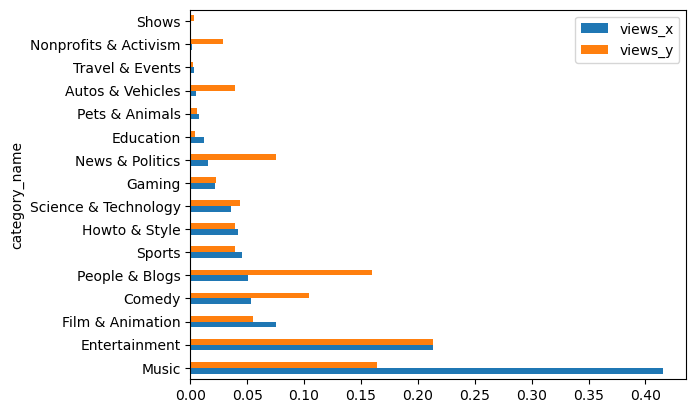

In [75]:
# Fix these to show percentages of total views

us_cat_view_median = ((us_df_reduced.groupby("category_name")["views"].sum())/(us_df_reduced["views"].sum())).sort_values(ascending=False)
ru_cat_view_median = ((ru_df_reduced.groupby("category_name")["views"].sum())/(ru_df_reduced["views"].sum())).sort_values(ascending=False)
pd.merge(us_cat_view_median, ru_cat_view_median, on="category_name").plot(kind="barh")

plt.show()


Replicate this plotting process as a function:

Function should accept a list of categories and a dataframe for whatever country we want to see.

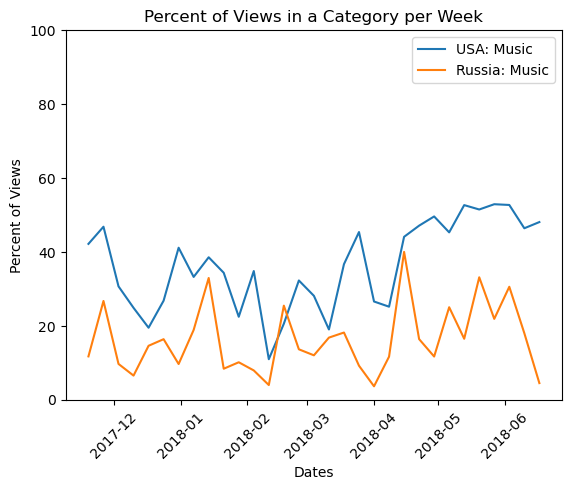

In [ ]:
cat_dict = {'USA': [["Music"], us_df_reduced],
            'Russia': [["Music"], ru_df_reduced]}
for country in cat_dict:
    for cat in cat_dict[country][0]:
        plot_categories(cat_dict[country][1], cat, country)

plt.legend()
plt.title("Percent of Views in a Category per Week")
plt.ylabel("Percent of Views")
plt.xlabel("Dates")
plt.xticks(rotation=45)
plt.ylim(0,100)
plt.show()

### Plot Russian Views